# Custom CNN Model Trained from Scratch for Error Classification

This notebook implements a custom Convolutional Neural Network trained from scratch to classify different types of application errors.

## 1. Import Libraries

In [12]:
# Ensure required packages are installed in the active notebook environment.
import importlib
import subprocess
import sys


def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"OK: {package_name} already installed")
    except ModuleNotFoundError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("torch")
ensure_package("torchvision")
ensure_package("scikit-learn", "sklearn")
ensure_package("seaborn")

OK: torch already installed
OK: torchvision already installed
OK: scikit-learn already installed
OK: seaborn already installed


In [13]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.12.0+cpu
Device: cpu


## 2. Data Exploration

In [14]:
# Define data path
data_dir = r"C:\Users\Lenovo\Desktop\UB\TFM\Data"

# Get all error categories
error_categories = os.listdir(data_dir)
error_categories = [cat for cat in error_categories if os.path.isdir(os.path.join(data_dir, cat))]
error_categories.sort()

print(f"Error Categories: {error_categories}")
print(f"Number of categories: {len(error_categories)}")

Error Categories: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Number of categories: 8


In [15]:
# Count images per category
image_counts = {}
image_extensions = ('.png', '.jpg', '.jpeg')

for category in error_categories:
    cat_path = os.path.join(data_dir, category)
    images = [f for f in os.listdir(cat_path) 
              if f.lower().endswith(image_extensions)]
    image_counts[category] = len(images)
    print(f"{category}: {len(images)} images")

total_images = sum(image_counts.values())
print(f"\nTotal images: {total_images}")

Banner aplicación: 87 images
Cierre aplicación: 126 images
Error aplicativo: 143 images
Error funcional: 96 images
Error terminal: 377 images
Indeterminado: 99 images
Revisión circuito: 783 images
Timeout: 132 images

Total images: 1843


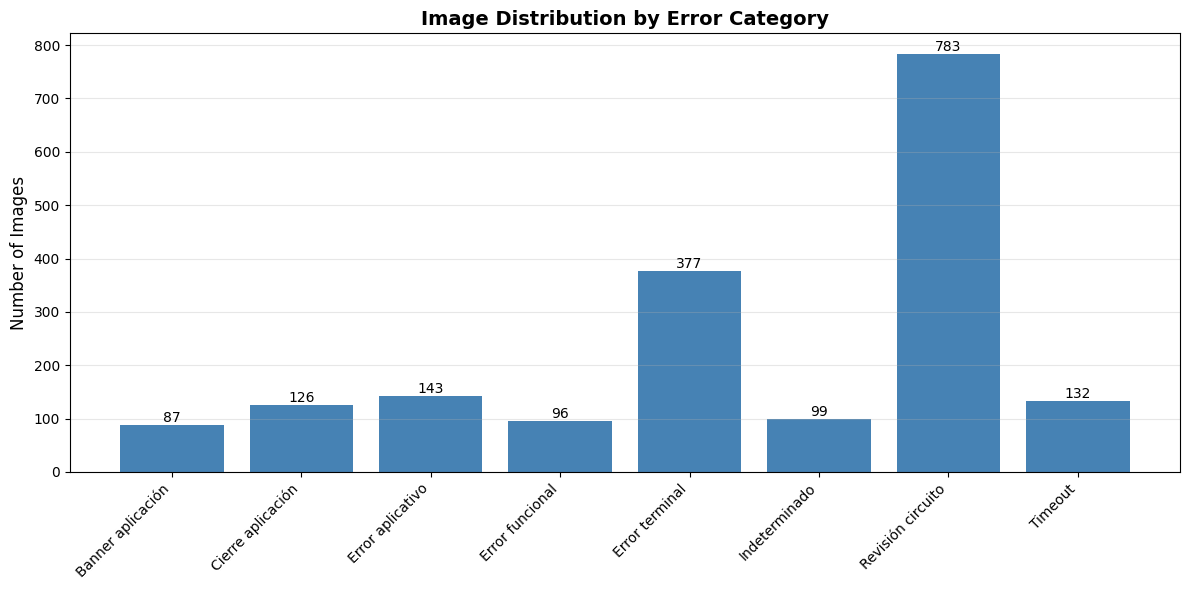


Data Summary:
            Category  Image Count Percentage
0  Banner aplicación           87       4.7%
1  Cierre aplicación          126       6.8%
2   Error aplicativo          143       7.8%
3    Error funcional           96       5.2%
4     Error terminal          377      20.5%
5      Indeterminado           99       5.4%
6  Revisión circuito          783      42.5%
7            Timeout          132       7.2%


In [16]:
# Visualize data distribution
fig, ax = plt.subplots(figsize=(12, 6))
categories = list(image_counts.keys())
counts = list(image_counts.values())

bars = ax.bar(range(len(categories)), counts, color='steelblue')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution by Error Category', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create summary dataframe
summary_df = pd.DataFrame({
    'Category': categories,
    'Image Count': counts,
    'Percentage': [f"{100*count/total_images:.1f}%" for count in counts]
})
print("\nData Summary:")
print(summary_df)

## 3. Data Preparation

In [17]:
# Define hyperparameters
IMAGE_SIZE = (224, 224)  # Standard image size for the CNN
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
NUM_WORKERS = 0
BORDER_CROP = 120  # Crop pixels from top/bottom (mobile border effect)

print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Validation Split: {VALIDATION_SPLIT}")
print(f"Border Crop: {BORDER_CROP} pixels")

Image Size: (224, 224)
Batch Size: 32
Validation Split: 0.2
Border Crop: 120 pixels


In [18]:
# Build transforms with crop preprocessing
mobile_border_crop = transforms.Lambda(lambda img: img.crop((0, BORDER_CROP, img.width, img.height - BORDER_CROP)))

train_transform = transforms.Compose([
    mobile_border_crop,
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

minority_train_transform = transforms.Compose([
    mobile_border_crop,
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=3,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05),
            shear=2,
        )
    ], p=0.8),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
            saturation=0.05,
            hue=0.02,
        )
    ], p=0.6),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    mobile_border_crop,
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets
full_dataset_no_tf = datasets.ImageFolder(root=data_dir)
class_names = full_dataset_no_tf.classes
num_classes = len(class_names)

labels = np.array(full_dataset_no_tf.targets)
indices = np.arange(len(full_dataset_no_tf))
class_counts = {class_name: image_counts[class_name] for class_name in class_names}
minority_count_threshold = int(np.median(list(class_counts.values())))
minority_class_names = [
    class_name for class_name, count in class_counts.items()
    if count <= minority_count_threshold
]
minority_class_indices = {
    full_dataset_no_tf.class_to_idx[class_name]
    for class_name in minority_class_names
}

train_indices, val_indices = train_test_split(
    indices,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=labels,
)

train_dataset_base = datasets.ImageFolder(root=data_dir, transform=train_transform)
minority_train_dataset_base = datasets.ImageFolder(root=data_dir, transform=minority_train_transform)
val_dataset_base = datasets.ImageFolder(root=data_dir, transform=val_transform)

minority_train_indices = [idx for idx in train_indices if labels[idx] in minority_class_indices]
majority_train_indices = [idx for idx in train_indices if labels[idx] not in minority_class_indices]
minority_repeat_factor = 2

train_dataset = ConcatDataset([
    Subset(minority_train_dataset_base, minority_train_indices)
    for _ in range(minority_repeat_factor)
] + [
    Subset(train_dataset_base, majority_train_indices)
])
val_dataset = Subset(val_dataset_base, val_indices)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Minority count threshold: {minority_count_threshold}")
print(f"Minority classes with stronger augmentation: {minority_class_names}")
print(f"Minority training samples: {len(minority_train_indices)}")
print(f"Majority training samples: {len(majority_train_indices)}")
print(f"Minority repeat factor: {minority_repeat_factor}")
print(f"Training samples after augmentation repeats: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Number of classes: 8
Class names: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Minority count threshold: 129
Minority classes with stronger augmentation: ['Banner aplicación', 'Cierre aplicación', 'Error funcional', 'Indeterminado']
Minority training samples: 327
Majority training samples: 1147
Minority repeat factor: 2
Training samples after augmentation repeats: 1801
Validation samples: 369


In [19]:
# Build dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 57
Validation batches: 12


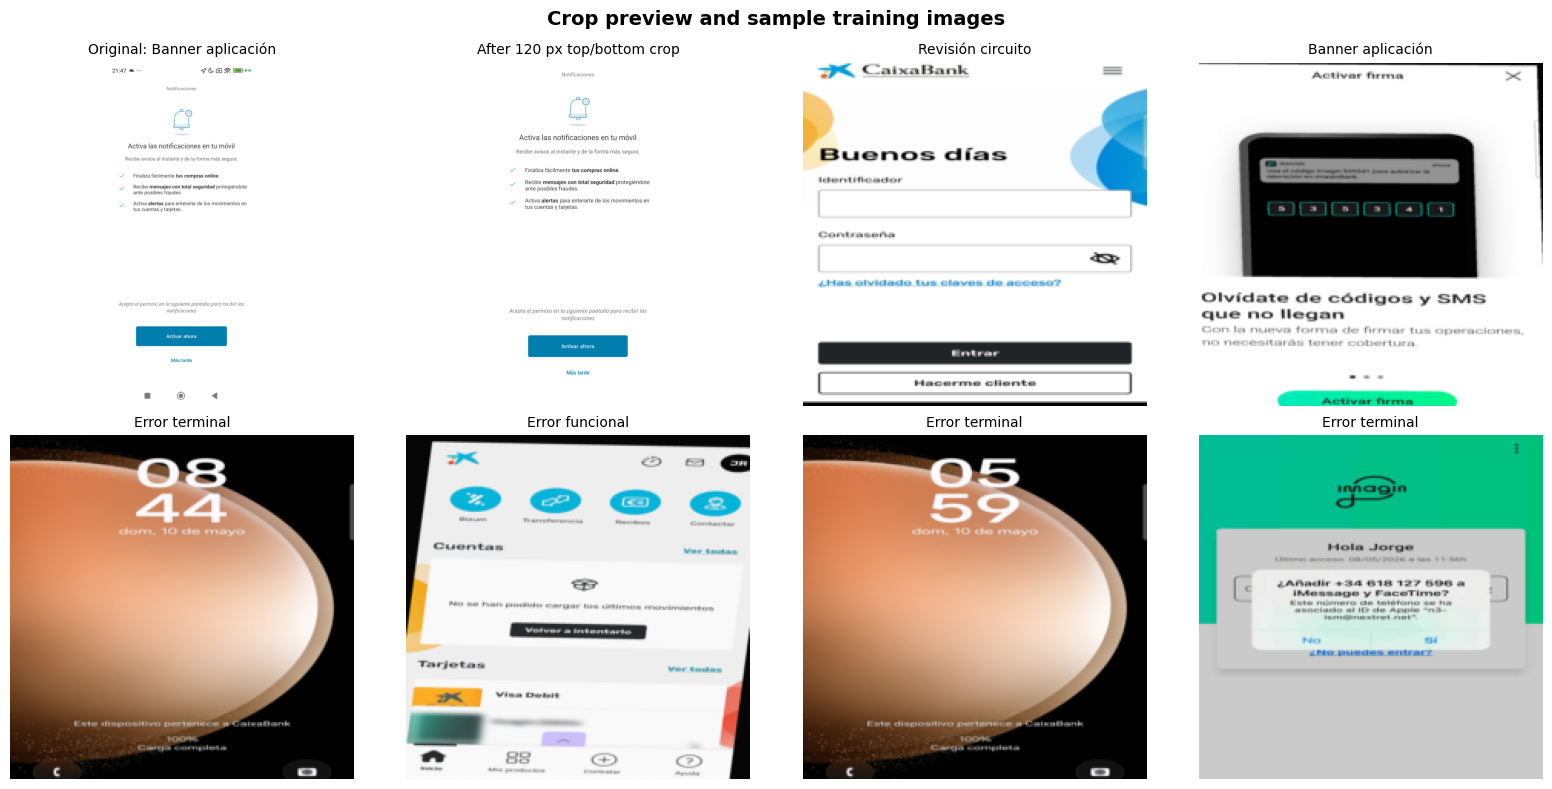

In [20]:
# Inverse normalization for visualization
inv_normalize = transforms.Compose([
    transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                          std=[1/0.229, 1/0.224, 1/0.225])
])

# Visualize sample images and the border crop effect
sample_image, sample_label = full_dataset_no_tf[0]
sample_cropped = mobile_border_crop(sample_image)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(sample_image)
axes[0].set_title(f"Original: {class_names[sample_label]}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(sample_cropped)
axes[1].set_title(f"After {BORDER_CROP} px top/bottom crop", fontsize=10)
axes[1].axis("off")

images, labels = next(iter(train_loader))
for idx in range(2, min(8, len(images))):
    ax = axes[idx]
    img = inv_normalize(images[idx - 2]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[int(labels[idx - 2])], fontsize=10)
    ax.axis("off")

plt.suptitle("Crop preview and sample training images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Build Custom CNN Model from Scratch

In [21]:
# Define a custom CNN architecture trained from scratch
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 -> 112
            nn.Dropout(0.25),
        )
        
        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 -> 56
            nn.Dropout(0.25),
        )
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 -> 28
            nn.Dropout(0.25),
        )
        
        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14
            nn.Dropout(0.25),
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialize model
model = CustomCNN(num_classes=num_classes)
model = model.to(device)

print("Custom CNN Model Architecture:")
print(model)

Custom CNN Model Architecture:
CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
 

In [22]:
# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nAll parameters are trainable (no frozen layers)")


Total parameters: 1,273,896
Trainable parameters: 1,273,896

All parameters are trainable (no frozen layers)


In [23]:
# Configure loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

print("Loss and optimizer configured.")
print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=1e-3, weight_decay=1e-5)")

Loss and optimizer configured.
Loss function: CrossEntropyLoss
Optimizer: Adam (lr=1e-3, weight_decay=1e-5)


## 5. Train Model

In [24]:
# Training controls
EPOCHS = 30
PATIENCE = 7
LR_FACTOR = 0.5
LR_PATIENCE = 8
MIN_LR = 1e-7

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR,
)

print("Training controls configured.")
print(f"Max epochs: {EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")

Training controls configured.
Max epochs: 30
Early stopping patience: 7


In [25]:
# Train the model with early stopping
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation phase
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"loss: {train_loss:.4f} | acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best model weights.")

Epoch 1/30 | loss: 1.4132 | acc: 0.4964 | val_loss: 3.2346 | val_acc: 0.6098
Epoch 5/30 | loss: 0.5456 | acc: 0.8107 | val_loss: 0.4380 | val_acc: 0.7913
Epoch 10/30 | loss: 0.3075 | acc: 0.9028 | val_loss: 0.1765 | val_acc: 0.9512
Epoch 15/30 | loss: 0.2228 | acc: 0.9223 | val_loss: 0.2619 | val_acc: 0.9187
Epoch 20/30 | loss: 0.2978 | acc: 0.9095 | val_loss: 0.1788 | val_acc: 0.9350
Epoch 25/30 | loss: 0.1947 | acc: 0.9334 | val_loss: 0.1518 | val_acc: 0.9350
Epoch 30/30 | loss: 0.1605 | acc: 0.9528 | val_loss: 0.1029 | val_acc: 0.9621
Restored best model weights.


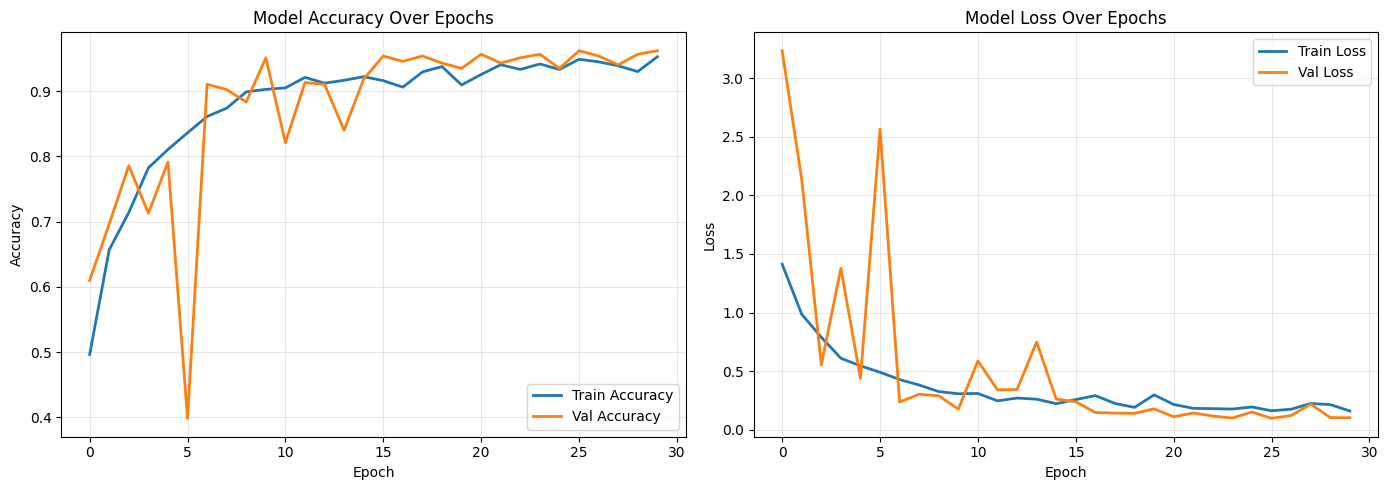


Training Summary:
Total epochs trained: 30
Best val accuracy: 0.9621
Best val loss: 0.0977
Final train accuracy: 0.9528
Final val accuracy: 0.9621


In [26]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"Total epochs trained: {len(history['loss'])}")
print(f"Best val accuracy: {max(history['val_accuracy']):.4f}")
print(f"Best val loss: {min(history['val_loss']):.4f}")
print(f"Final train accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final val accuracy: {history['val_accuracy'][-1]:.4f}")

## 6. Model Evaluation

In [27]:
# Evaluate final model on validation set
model.eval()

final_val_loss = history["val_loss"][-1]
final_val_accuracy = history["val_accuracy"][-1]

print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

Final Validation Loss: 0.1029
Final Validation Accuracy: 0.9621


In [28]:
# Get predictions for confusion matrix and classification report
y_pred = []
y_true = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Validation Accuracy (sklearn): {accuracy_score(y_true, y_pred):.4f}")

Predictions shape: (369,)
True labels shape: (369,)
Validation Accuracy (sklearn): 0.9621


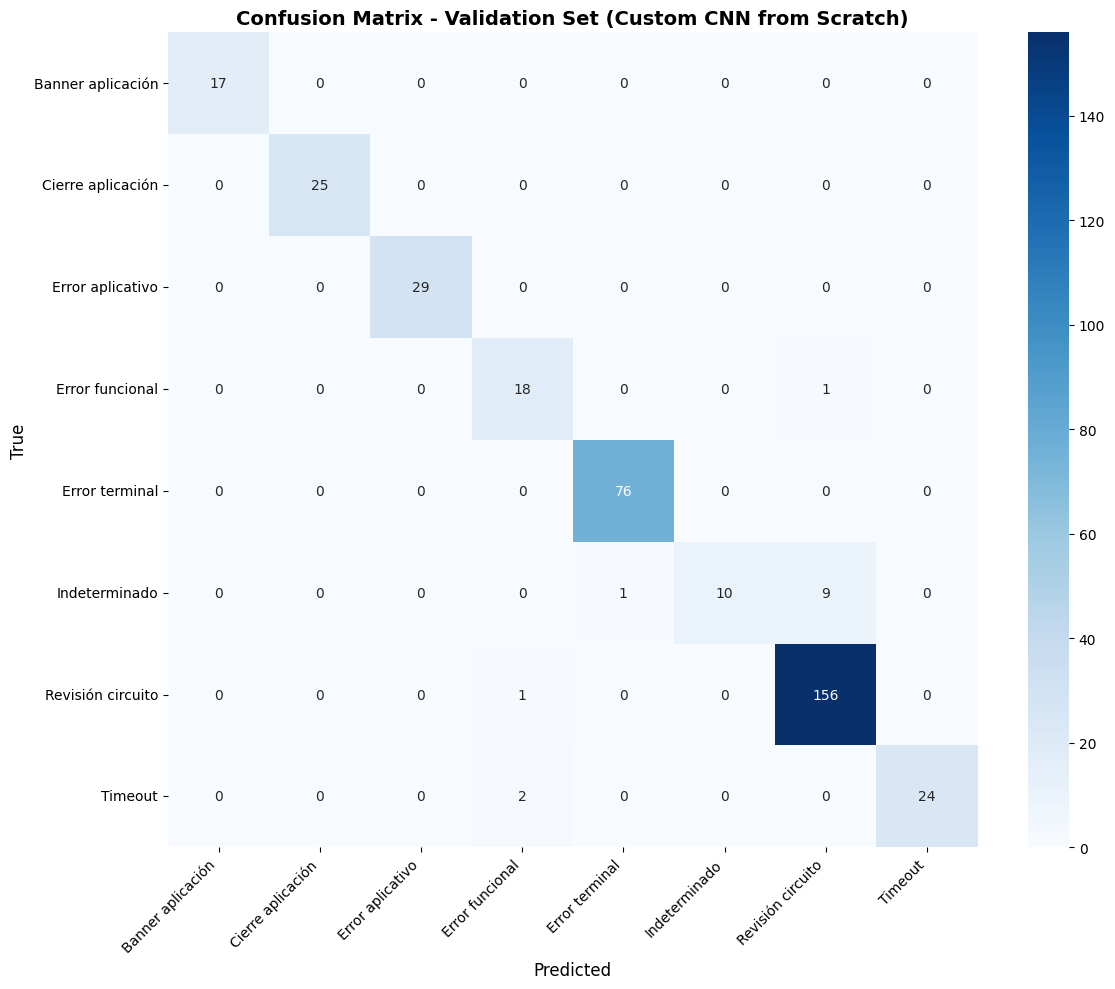

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix - Validation Set (Custom CNN from Scratch)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Classification Report
print("Classification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        17
Cierre aplicación       1.00      1.00      1.00        25
 Error aplicativo       1.00      1.00      1.00        29
  Error funcional       0.86      0.95      0.90        19
   Error terminal       0.99      1.00      0.99        76
    Indeterminado       1.00      0.50      0.67        20
Revisión circuito       0.94      0.99      0.97       157
          Timeout       1.00      0.92      0.96        26

         accuracy                           0.96       369
        macro avg       0.97      0.92      0.94       369
     weighted avg       0.96      0.96      0.96       369



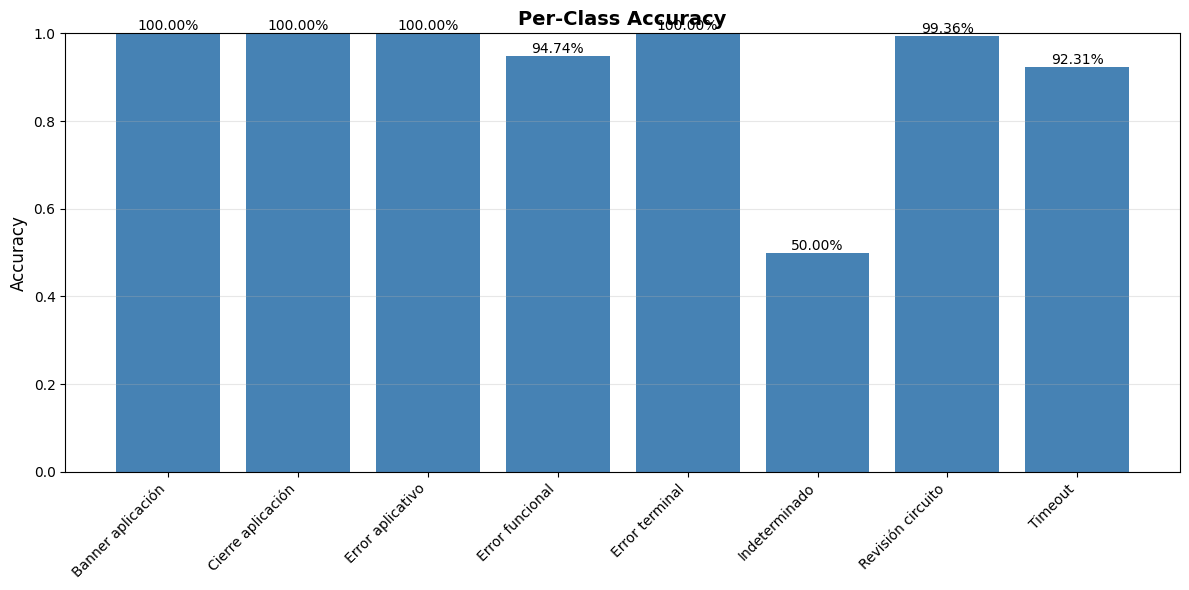


Per-Class Accuracy:
Banner aplicación: 100.00%
Cierre aplicación: 100.00%
Error aplicativo: 100.00%
Error funcional: 94.74%
Error terminal: 100.00%
Indeterminado: 50.00%
Revisión circuito: 99.36%
Timeout: 92.31%


In [31]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(class_names)), per_class_acc, color='steelblue')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for class_name, acc in zip(class_names, per_class_acc):
    print(f"{class_name}: {acc:.2%}")

## 7. Save Model

In [33]:
# Save model weights
model_save_path = r"C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_from_scratch_DA.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Save class names for later inference
class_names_path = r"C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\class_names.json"
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=4)
print(f"Class names saved to {class_names_path}")

Model saved to C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_from_scratch_DA.pth
Class names saved to C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\class_names.json


In [35]:
# Save training history
history_path = r"C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_training_history.json"
history_to_save = {
    'accuracy': [float(acc) for acc in history['accuracy']],
    'val_accuracy': [float(acc) for acc in history['val_accuracy']],
    'loss': [float(loss) for loss in history['loss']],
    'val_loss': [float(loss) for loss in history['val_loss']],
}

with open(history_path, 'w') as f:
    json.dump(history_to_save, f, indent=4)
print(f"Training history saved to {history_path}")

Training history saved to C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_training_history.json


## 8. Model Inference Example

In [36]:
# Function for single image inference
def predict_image(image_path, model, transform, device, class_names):
    from PIL import Image
    
    model.eval()
    image = Image.open(image_path).convert('RGB')
    
    # Apply transforms
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    
    return {
        'predicted_class': class_names[predicted_class],
        'confidence': probabilities[0][predicted_class].item(),
        'all_probabilities': {class_names[i]: prob.item() for i, prob in enumerate(probabilities[0])}
    }

print("Inference function defined. Ready to predict on new images.")

Inference function defined. Ready to predict on new images.


In [37]:
# Example inference on a validation image
from PIL import Image

# Get first image from validation set
val_image, val_label = val_dataset[0]

# Get prediction
model.eval()
with torch.no_grad():
    val_image_tensor = val_image.unsqueeze(0).to(device)
    logits = model(val_image_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()

predicted_class = class_names[predicted_class_idx]
true_class = class_names[val_label]
confidence = probabilities[0][predicted_class_idx].item()

print(f"True class: {true_class}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
print(f"\nAll class probabilities:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {probabilities[0][i].item():.4f}")

True class: Error aplicativo
Predicted class: Error aplicativo
Confidence: 0.9960

All class probabilities:
  Banner aplicación: 0.0029
  Cierre aplicación: 0.0000
  Error aplicativo: 0.9960
  Error funcional: 0.0000
  Error terminal: 0.0001
  Indeterminado: 0.0003
  Revisión circuito: 0.0005
  Timeout: 0.0001


## 9. Model Summary and Comparison

In [38]:
# Create a summary report
print("\n" + "="*70)
print("CUSTOM CNN FROM SCRATCH - MODEL SUMMARY")
print("="*70)

print(f"\nModel Configuration:")
print(f"  - Architecture: Custom 4-layer CNN")
print(f"  - Total Parameters: {total_params:,}")
print(f"  - Trainable Parameters: {trainable_params:,}")
print(f"  - Training Strategy: From scratch (no pre-trained weights)")

print(f"\nData Configuration:")
print(f"  - Image Size: {IMAGE_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Training Samples: {len(train_dataset)}")
print(f"  - Validation Samples: {len(val_dataset)}")
print(f"  - Number of Classes: {num_classes}")
print(f"  - Classes: {', '.join(class_names)}")

print(f"\nTraining Configuration:")
print(f"  - Optimizer: Adam (lr=1e-3)")
print(f"  - Loss Function: CrossEntropyLoss")
print(f"  - Max Epochs: {EPOCHS}")
print(f"  - Early Stopping Patience: {PATIENCE}")
print(f"  - Epochs Trained: {len(history['loss'])}")

print(f"\nPerformance Metrics:")
print(f"  - Best Validation Accuracy: {max(history['val_accuracy']):.4f}")
print(f"  - Best Validation Loss: {min(history['val_loss']):.4f}")
print(f"  - Final Validation Accuracy: {history['val_accuracy'][-1]:.4f}")
print(f"  - Final Training Accuracy: {history['accuracy'][-1]:.4f}")

print(f"\nPer-Class Performance (on validation set):")
for class_name, acc in zip(class_names, per_class_acc):
    print(f"  - {class_name}: {acc:.2%}")

print("\n" + "="*70)


CUSTOM CNN FROM SCRATCH - MODEL SUMMARY

Model Configuration:
  - Architecture: Custom 4-layer CNN
  - Total Parameters: 1,273,896
  - Trainable Parameters: 1,273,896
  - Training Strategy: From scratch (no pre-trained weights)

Data Configuration:
  - Image Size: (224, 224)
  - Batch Size: 32
  - Training Samples: 1801
  - Validation Samples: 369
  - Number of Classes: 8
  - Classes: Banner aplicación, Cierre aplicación, Error aplicativo, Error funcional, Error terminal, Indeterminado, Revisión circuito, Timeout

Training Configuration:
  - Optimizer: Adam (lr=1e-3)
  - Loss Function: CrossEntropyLoss
  - Max Epochs: 30
  - Early Stopping Patience: 7
  - Epochs Trained: 30

Performance Metrics:
  - Best Validation Accuracy: 0.9621
  - Best Validation Loss: 0.0977
  - Final Validation Accuracy: 0.9621
  - Final Training Accuracy: 0.9528

Per-Class Performance (on validation set):
  - Banner aplicación: 100.00%
  - Cierre aplicación: 100.00%
  - Error aplicativo: 100.00%
  - Error func